# EHR Data Exploration

This notebook explores Electronic Health Record (EHR) data from:
- **Mount Sinai**: Drug-disease associations with statistical measures
- **UK Biobank**: Drug-cancer associations with odds ratios

These data help assess prevention risk given drug exposure to diseases.

## 1. Import Libraries and Load Data

In [1]:
import sys
sys.path.insert(0, '..')
import os
os.chdir('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Mount Sinai data
mount_sinai_file = Path("EHR_Results/mount_sinai_drug_disease.csv")
print(f"Loading Mount Sinai data from {mount_sinai_file}...")
mount_sinai_df = pd.read_csv(mount_sinai_file, low_memory=False)
print(f"Loaded {len(mount_sinai_df):,} records")
print(f"Columns: {len(mount_sinai_df.columns)}")
print(f"\nColumn names:")
print(list(mount_sinai_df.columns))

Loading Mount Sinai data from EHR_Results/mount_sinai_drug_disease.csv...
Loaded 41,120 records
Columns: 33

Column names:
['Drug Chembl ID', 'ICD10', 'logit_or', 'logit_ci_lower', 'logit_ci_upper', 'logit_p', 'raw_or', 'raw_fisher_p', 'exposed_occurred(a)', 'exposed_no_occurred(b)', 'no_exposed_occurred(c)', 'no_exposed_no_occurred(d)', 'cox_hr', 'cox_ci_lower', 'cox_ci_upper', 'cox_p', 'Disease Description', 'Drug Name', 'Chembl ID', 'DrugBank ID', 'Drug Description', 'IUPAC Name', 'Molecular Weight', 'SMILES', 'ATC Code', 'ATC Level_0_code', 'ATC Level_0_name', 'ATC Level_1_code', 'ATC Level_1_name', 'ATC Level_2_code', 'ATC Level_2_name', 'ATC Level_3_code', 'ATC Level_3_name']


In [3]:
# Load UK Biobank data
uk_biobank_file = Path("EHR_Results/uk_biobank_drug_disease.csv")
print(f"Loading UK Biobank data from {uk_biobank_file}...")
uk_biobank_df = pd.read_csv(uk_biobank_file, low_memory=False)
print(f"Loaded {len(uk_biobank_df):,} records")
print(f"Columns: {len(uk_biobank_df.columns)}")
print(f"\nColumn names:")
print(list(uk_biobank_df.columns))

Loading UK Biobank data from EHR_Results/uk_biobank_drug_disease.csv...
Loaded 693 records
Columns: 24

Column names:
['Drug Chembl ID', 'ICD10', 'odds_ratio', 'drug_cancer', 'drug_no_cancer', 'no_drug_cancer', 'no_drug_no_cancer', 'Disease Description', 'Drug Name', 'Chembl ID', 'DrugBank ID', 'Drug Description', 'IUPAC Name', 'Molecular Weight', 'SMILES', 'ATC Code', 'ATC Level_0_code', 'ATC Level_0_name', 'ATC Level_1_code', 'ATC Level_1_name', 'ATC Level_2_code', 'ATC Level_2_name', 'ATC Level_3_code', 'ATC Level_3_name']


## 2. Explore Mount Sinai Data

In [4]:
print("=" * 80)
print("MOUNT SINAI DATA OVERVIEW")
print("=" * 80)
print(f"\nShape: {mount_sinai_df.shape}")
print(f"\nFirst few rows:")
display(mount_sinai_df.head(10))

MOUNT SINAI DATA OVERVIEW

Shape: (41120, 33)

First few rows:


,Drug Chembl ID,ICD10,logit_or,logit_ci_lower,logit_ci_upper,logit_p,raw_or,raw_fisher_p,exposed_occurred(a),exposed_no_occurred(b),...,SMILES,ATC Code,ATC Level_0_code,ATC Level_0_name,ATC Level_1_code,ATC Level_1_name,ATC Level_2_code,ATC Level_2_name,ATC Level_3_code,ATC Level_3_name
0,CHEMBL1060,I10,0.927641,0.906039,0.949758,4.163846e-10,0.927641,3.769057e-10,11200,111101,...,[Na+].[Na+].OP([O-])([O-])=O,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CHEMBL1098,P29,0.888357,0.867297,0.909929,4.019766e-22,0.888357,2.407313e-22,10779,98083,...,CCCCN1CCCCC1C(=O)NC1=C(C)C=CC=C1C,N01BB01,N01BB,Amides,N01B,"ANESTHETICS, LOCAL",N01,ANESTHETICS,N,NERVOUS SYSTEM
2,CHEMBL1098,P29,0.888357,0.867297,0.909929,4.019766e-22,0.888357,2.407313e-22,10779,98083,...,CCCCN1CCCCC1C(=O)NC1=C(C)C=CC=C1C,N01BB59,N01BB,Amides,N01B,"ANESTHETICS, LOCAL",N01,ANESTHETICS,N,NERVOUS SYSTEM
3,CHEMBL1098,P29,0.888357,0.867297,0.909929,4.019766e-22,0.888357,2.407313e-22,10779,98083,...,CCCCN1CCCCC1C(=O)NC1=C(C)C=CC=C1C,N01BB51,N01BB,Amides,N01B,"ANESTHETICS, LOCAL",N01,ANESTHETICS,N,NERVOUS SYSTEM
4,CHEMBL1215,I10,0.952914,0.929764,0.976641,1.212403e-04,0.952914,1.200212e-04,10496,90756,...,CNC[C@H](O)C1=CC(O)=CC=C1,S01FB01,S01FB,Sympathomimetics excl. antiglaucoma preparations,S01F,MYDRIATICS AND CYCLOPLEGICS,S01,OPHTHALMOLOGICALS,S,SENSORY ORGANS
5,CHEMBL1215,I10,0.952914,0.929764,0.976641,1.212403e-04,0.952914,1.200212e-04,10496,90756,...,CNC[C@H](O)C1=CC(O)=CC=C1,R01AB01,R01AB,"Sympathomimetics, combinations excl. corticost...",R01A,DECONGESTANTS AND OTHER NASAL PREPARATIONS FOR...,R01,NASAL PREPARATIONS,R,RESPIRATORY SYSTEM
6,CHEMBL1215,I10,0.952914,0.929764,0.976641,1.212403e-04,0.952914,1.200212e-04,10496,90756,...,CNC[C@H](O)C1=CC(O)=CC=C1,C01CA06,C01CA,Adrenergic and dopaminergic agents,C01C,CARDIAC STIMULANTS EXCL. CARDIAC GLYCOSIDES,C01,CARDIAC THERAPY,C,CARDIOVASCULAR SYSTEM
7,CHEMBL1215,I10,0.952914,0.929764,0.976641,1.212403e-04,0.952914,1.200212e-04,10496,90756,...,CNC[C@H](O)C1=CC(O)=CC=C1,R01AA04,R01AA,"Sympathomimetics, plain",R01A,DECONGESTANTS AND OTHER NASAL PREPARATIONS FOR...,R01,NASAL PREPARATIONS,R,RESPIRATORY SYSTEM
8,CHEMBL1215,I10,0.952914,0.929764,0.976641,1.212403e-04,0.952914,1.200212e-04,10496,90756,...,CNC[C@H](O)C1=CC(O)=CC=C1,S01FB51,S01FB,Sympathomimetics excl. antiglaucoma preparations,S01F,MYDRIATICS AND CYCLOPLEGICS,S01,OPHTHALMOLOGICALS,S,SENSORY ORGANS
9,CHEMBL1215,I10,0.952914,0.929764,0.976641,1.212403e-04,0.952914,1.200212e-04,10496,90756,...,CNC[C@H](O)C1=CC(O)=CC=C1,R01BA53,R01BA,Sympathomimetics,R01B,NASAL DECONGESTANTS FOR SYSTEMIC USE,R01,NASAL PREPARATIONS,R,RESPIRATORY SYSTEM


In [5]:
print("=" * 80)
print("MOUNT SINAI DATA STATISTICS")
print("=" * 80)

print(f"\nUnique drugs: {mount_sinai_df['Drug Chembl ID'].nunique() if 'Drug Chembl ID' in mount_sinai_df.columns else 'N/A'}")
print(f"Unique diseases (ICD10): {mount_sinai_df['ICD10'].nunique() if 'ICD10' in mount_sinai_df.columns else 'N/A'}")
print(f"Unique drug names: {mount_sinai_df['Drug Name'].nunique() if 'Drug Name' in mount_sinai_df.columns else 'N/A'}")
print(f"Unique disease descriptions: {mount_sinai_df['Disease Description'].nunique() if 'Disease Description' in mount_sinai_df.columns else 'N/A'}")

# Statistical measures
if 'logit_or' in mount_sinai_df.columns:
    print(f"\nLogit OR statistics:")
    print(mount_sinai_df['logit_or'].describe())

if 'cox_hr' in mount_sinai_df.columns:
    print(f"\nCox HR statistics:")
    print(mount_sinai_df['cox_hr'].describe())

MOUNT SINAI DATA STATISTICS

Unique drugs: 730
Unique diseases (ICD10): 964
Unique drug names: 719
Unique disease descriptions: 964

Logit OR statistics:
count    41120.000000
mean         0.485125
std          0.226148
min          0.001703
25%          0.304207
50%          0.493491
75%          0.666088
max          0.958512
Name: logit_or, dtype: float64

Cox HR statistics:
count    4.112000e+04
mean     4.900183e-01
std      2.296168e-01
min      7.344241e-09
25%      3.076816e-01
50%      5.016505e-01
75%      6.761762e-01
max      1.999879e+00
Name: cox_hr, dtype: float64


In [6]:
# Sample data with key columns
key_cols = ['Drug Chembl ID', 'Drug Name', 'ICD10', 'Disease Description', 
            'logit_or', 'logit_ci_lower', 'logit_ci_upper', 'logit_p',
            'cox_hr', 'cox_ci_lower', 'cox_ci_upper', 'cox_p']
available_cols = [col for col in key_cols if col in mount_sinai_df.columns]

print("Sample Mount Sinai associations:")
display(mount_sinai_df[available_cols].head(10))

Sample Mount Sinai associations:


,Drug Chembl ID,Drug Name,ICD10,Disease Description,logit_or,logit_ci_lower,logit_ci_upper,logit_p,cox_hr,cox_ci_lower,cox_ci_upper,cox_p
0,CHEMBL1060,Sodium Phosphate,I10,Essential (primary) hypertension,0.927641,0.906039,0.949758,4.163846e-10,0.923658,0.903153,0.944628,4.112339e-12
1,CHEMBL1098,Bupivacaine,P29,Cardiovascular disorders originating in the pe...,0.888357,0.867297,0.909929,4.019766e-22,0.858857,0.839550,0.878608,2.652060e-39
2,CHEMBL1098,Bupivacaine,P29,Cardiovascular disorders originating in the pe...,0.888357,0.867297,0.909929,4.019766e-22,0.858857,0.839550,0.878608,2.652060e-39
3,CHEMBL1098,Bupivacaine,P29,Cardiovascular disorders originating in the pe...,0.888357,0.867297,0.909929,4.019766e-22,0.858857,0.839550,0.878608,2.652060e-39
4,CHEMBL1215,Phenylephrine,I10,Essential (primary) hypertension,0.952914,0.929764,0.976641,1.212403e-04,0.922063,0.900853,0.943773,8.275072e-12
5,CHEMBL1215,Phenylephrine,I10,Essential (primary) hypertension,0.952914,0.929764,0.976641,1.212403e-04,0.922063,0.900853,0.943773,8.275072e-12
6,CHEMBL1215,Phenylephrine,I10,Essential (primary) hypertension,0.952914,0.929764,0.976641,1.212403e-04,0.922063,0.900853,0.943773,8.275072e-12
7,CHEMBL1215,Phenylephrine,I10,Essential (primary) hypertension,0.952914,0.929764,0.976641,1.212403e-04,0.922063,0.900853,0.943773,8.275072e-12
8,CHEMBL1215,Phenylephrine,I10,Essential (primary) hypertension,0.952914,0.929764,0.976641,1.212403e-04,0.922063,0.900853,0.943773,8.275072e-12
9,CHEMBL1215,Phenylephrine,I10,Essential (primary) hypertension,0.952914,0.929764,0.976641,1.212403e-04,0.922063,0.900853,0.943773,8.275072e-12


## 3. Explore UK Biobank Data

In [7]:
print("=" * 80)
print("UK BIOBANK DATA OVERVIEW")
print("=" * 80)
print(f"\nShape: {uk_biobank_df.shape}")
print(f"\nFirst few rows:")
display(uk_biobank_df.head(10))

UK BIOBANK DATA OVERVIEW

Shape: (693, 24)

First few rows:


,Drug Chembl ID,ICD10,odds_ratio,drug_cancer,drug_no_cancer,no_drug_cancer,no_drug_no_cancer,Disease Description,Drug Name,Chembl ID,...,SMILES,ATC Code,ATC Level_0_code,ATC Level_0_name,ATC Level_1_code,ATC Level_1_name,ATC Level_2_code,ATC Level_2_name,ATC Level_3_code,ATC Level_3_name
0,CHEMBL716,C44,0.136,9,737,24258,269795,Other and unspecified malignant neoplasm of skin,Quetiapine,CHEMBL716,...,OCCOCCN1CCN(CC1)C1=NC2=CC=CC=C2SC2=CC=CC=C12,N05AH04,N05AH,"Diazepines, oxazepines, thiazepines and oxepines",N05A,ANTIPSYCHOTICS,N05,PSYCHOLEPTICS,N,NERVOUS SYSTEM
1,CHEMBL716,C61,0.216,8,739,14024,280028,Malignant neoplasm of prostate,Quetiapine,CHEMBL716,...,OCCOCCN1CCN(CC1)C1=NC2=CC=CC=C2SC2=CC=CC=C12,N05AH04,N05AH,"Diazepines, oxazepines, thiazepines and oxepines",N05A,ANTIPSYCHOTICS,N05,PSYCHOLEPTICS,N,NERVOUS SYSTEM
2,CHEMBL716,C50,0.067,3,739,16865,277189,Malignant neoplasm of breast,Quetiapine,CHEMBL716,...,OCCOCCN1CCN(CC1)C1=NC2=CC=CC=C2SC2=CC=CC=C12,N05AH04,N05AH,"Diazepines, oxazepines, thiazepines and oxepines",N05A,ANTIPSYCHOTICS,N05,PSYCHOLEPTICS,N,NERVOUS SYSTEM
3,CHEMBL1138,C61,0.412,800,37350,12645,243417,Malignant neoplasm of prostate,Ezetimibe,CHEMBL1138,...,[H][C@]1(CC[C@H](O)C2=CC=C(F)C=C2)C(=O)N(C2=CC...,C10BA02,C10BA,Combinations of various lipid modifying agents,C10B,"LIPID MODIFYING AGENTS, COMBINATIONS",C10,LIPID MODIFYING AGENTS,C,CARDIOVASCULAR SYSTEM
4,CHEMBL1138,C61,0.412,800,37350,12645,243417,Malignant neoplasm of prostate,Ezetimibe,CHEMBL1138,...,[H][C@]1(CC[C@H](O)C2=CC=C(F)C=C2)C(=O)N(C2=CC...,C10BA11,C10BA,Combinations of various lipid modifying agents,C10B,"LIPID MODIFYING AGENTS, COMBINATIONS",C10,LIPID MODIFYING AGENTS,C,CARDIOVASCULAR SYSTEM
5,CHEMBL1138,C61,0.412,800,37350,12645,243417,Malignant neoplasm of prostate,Ezetimibe,CHEMBL1138,...,[H][C@]1(CC[C@H](O)C2=CC=C(F)C=C2)C(=O)N(C2=CC...,C10BA10,C10BA,Combinations of various lipid modifying agents,C10B,"LIPID MODIFYING AGENTS, COMBINATIONS",C10,LIPID MODIFYING AGENTS,C,CARDIOVASCULAR SYSTEM
6,CHEMBL1138,C61,0.412,800,37350,12645,243417,Malignant neoplasm of prostate,Ezetimibe,CHEMBL1138,...,[H][C@]1(CC[C@H](O)C2=CC=C(F)C=C2)C(=O)N(C2=CC...,C10BA05,C10BA,Combinations of various lipid modifying agents,C10B,"LIPID MODIFYING AGENTS, COMBINATIONS",C10,LIPID MODIFYING AGENTS,C,CARDIOVASCULAR SYSTEM
7,CHEMBL1138,C61,0.412,800,37350,12645,243417,Malignant neoplasm of prostate,Ezetimibe,CHEMBL1138,...,[H][C@]1(CC[C@H](O)C2=CC=C(F)C=C2)C(=O)N(C2=CC...,C10BA12,C10BA,Combinations of various lipid modifying agents,C10B,"LIPID MODIFYING AGENTS, COMBINATIONS",C10,LIPID MODIFYING AGENTS,C,CARDIOVASCULAR SYSTEM
8,CHEMBL1138,C61,0.412,800,37350,12645,243417,Malignant neoplasm of prostate,Ezetimibe,CHEMBL1138,...,[H][C@]1(CC[C@H](O)C2=CC=C(F)C=C2)C(=O)N(C2=CC...,C10AX09,C10AX,Other lipid modifying agents,C10A,"LIPID MODIFYING AGENTS, PLAIN",C10,LIPID MODIFYING AGENTS,C,CARDIOVASCULAR SYSTEM
9,CHEMBL1138,C61,0.412,800,37350,12645,243417,Malignant neoplasm of prostate,Ezetimibe,CHEMBL1138,...,[H][C@]1(CC[C@H](O)C2=CC=C(F)C=C2)C(=O)N(C2=CC...,C10BA06,C10BA,Combinations of various lipid modifying agents,C10B,"LIPID MODIFYING AGENTS, COMBINATIONS",C10,LIPID MODIFYING AGENTS,C,CARDIOVASCULAR SYSTEM


In [8]:
print("=" * 80)
print("UK BIOBANK DATA STATISTICS")
print("=" * 80)

print(f"\nUnique drugs: {uk_biobank_df['Drug Chembl ID'].nunique() if 'Drug Chembl ID' in uk_biobank_df.columns else 'N/A'}")
print(f"Unique diseases (ICD10): {uk_biobank_df['ICD10'].nunique() if 'ICD10' in uk_biobank_df.columns else 'N/A'}")
print(f"Unique drug names: {uk_biobank_df['Drug Name'].nunique() if 'Drug Name' in uk_biobank_df.columns else 'N/A'}")
print(f"Unique disease descriptions: {uk_biobank_df['Disease Description'].nunique() if 'Disease Description' in uk_biobank_df.columns else 'N/A'}")

# Odds ratio statistics
if 'odds_ratio' in uk_biobank_df.columns:
    print(f"\nOdds Ratio statistics:")
    print(uk_biobank_df['odds_ratio'].describe())

UK BIOBANK DATA STATISTICS

Unique drugs: 143
Unique diseases (ICD10): 20
Unique drug names: 143
Unique disease descriptions: 20

Odds Ratio statistics:
count    693.000000
mean       0.253316
std        0.187580
min        0.003000
25%        0.109000
50%        0.202000
75%        0.340000
max        1.301000
Name: odds_ratio, dtype: float64


In [9]:
# Sample data with key columns
key_cols = ['Drug Chembl ID', 'Drug Name', 'ICD10', 'Disease Description', 
            'odds_ratio', 'drug_cancer', 'drug_no_cancer', 
            'no_drug_cancer', 'no_drug_no_cancer']
available_cols = [col for col in key_cols if col in uk_biobank_df.columns]

print("Sample UK Biobank associations:")
display(uk_biobank_df[available_cols].head(10))

Sample UK Biobank associations:


,Drug Chembl ID,Drug Name,ICD10,Disease Description,odds_ratio,drug_cancer,drug_no_cancer,no_drug_cancer,no_drug_no_cancer
0,CHEMBL716,Quetiapine,C44,Other and unspecified malignant neoplasm of skin,0.136,9,737,24258,269795
1,CHEMBL716,Quetiapine,C61,Malignant neoplasm of prostate,0.216,8,739,14024,280028
2,CHEMBL716,Quetiapine,C50,Malignant neoplasm of breast,0.067,3,739,16865,277189
3,CHEMBL1138,Ezetimibe,C61,Malignant neoplasm of prostate,0.412,800,37350,12645,243417
4,CHEMBL1138,Ezetimibe,C61,Malignant neoplasm of prostate,0.412,800,37350,12645,243417
5,CHEMBL1138,Ezetimibe,C61,Malignant neoplasm of prostate,0.412,800,37350,12645,243417
6,CHEMBL1138,Ezetimibe,C61,Malignant neoplasm of prostate,0.412,800,37350,12645,243417
7,CHEMBL1138,Ezetimibe,C61,Malignant neoplasm of prostate,0.412,800,37350,12645,243417
8,CHEMBL1138,Ezetimibe,C61,Malignant neoplasm of prostate,0.412,800,37350,12645,243417
9,CHEMBL1138,Ezetimibe,C61,Malignant neoplasm of prostate,0.412,800,37350,12645,243417


## 4. Prevention Risk Analysis

### Understanding Risk Measures:
- **OR < 1** (or HR < 1): Drug may be protective (reduces risk)
- **OR > 1** (or HR > 1): Drug may increase risk
- **OR = 1** (or HR = 1): No association

In [10]:
# Mount Sinai: Protective associations (OR < 1, significant)
if 'logit_or' in mount_sinai_df.columns and 'logit_p' in mount_sinai_df.columns:
    protective = mount_sinai_df[
        (mount_sinai_df['logit_or'] < 1) & 
        (mount_sinai_df['logit_p'] < 0.05)
    ].copy()
    
    print(f"Mount Sinai - Protective associations (OR < 1, p < 0.05): {len(protective):,}")
    print(f"\nTop 10 most protective associations:")
    top_protective = protective.nsmallest(10, 'logit_or')
    display_cols = ['Drug Name', 'Disease Description', 'logit_or', 'logit_ci_lower', 'logit_ci_upper', 'logit_p']
    available = [col for col in display_cols if col in top_protective.columns]
    display(top_protective[available])

Mount Sinai - Protective associations (OR < 1, p < 0.05): 39,361

Top 10 most protective associations:


,Drug Name,Disease Description,logit_or,logit_ci_lower,logit_ci_upper,logit_p
37696,Prednisolone,Liveborn infants according to place of birth a...,0.001703,0.000426,0.006815,2.039498e-19
37697,Prednisolone,Liveborn infants according to place of birth a...,0.001703,0.000426,0.006815,2.039498e-19
37698,Prednisolone,Liveborn infants according to place of birth a...,0.001703,0.000426,0.006815,2.039498e-19
37699,Prednisolone,Liveborn infants according to place of birth a...,0.001703,0.000426,0.006815,2.039498e-19
37700,Prednisolone,Liveborn infants according to place of birth a...,0.001703,0.000426,0.006815,2.039498e-19
37701,Prednisolone,Liveborn infants according to place of birth a...,0.001703,0.000426,0.006815,2.039498e-19
37702,Prednisolone,Liveborn infants according to place of birth a...,0.001703,0.000426,0.006815,2.039498e-19
37703,Prednisolone,Liveborn infants according to place of birth a...,0.001703,0.000426,0.006815,2.039498e-19
37704,Prednisolone,Liveborn infants according to place of birth a...,0.001703,0.000426,0.006815,2.039498e-19
37705,Prednisolone,Liveborn infants according to place of birth a...,0.001703,0.000426,0.006815,2.039498e-19


In [11]:
# UK Biobank: Protective associations (OR < 1)
if 'odds_ratio' in uk_biobank_df.columns:
    protective_ukb = uk_biobank_df[uk_biobank_df['odds_ratio'] < 1].copy()
    
    print(f"UK Biobank - Protective associations (OR < 1): {len(protective_ukb):,}")
    print(f"\nTop 10 most protective associations:")
    top_protective_ukb = protective_ukb.nsmallest(10, 'odds_ratio')
    display_cols = ['Drug Name', 'Disease Description', 'odds_ratio', 
                   'drug_cancer', 'drug_no_cancer', 'no_drug_cancer', 'no_drug_no_cancer']
    available = [col for col in display_cols if col in top_protective_ukb.columns]
    display(top_protective_ukb[available])

UK Biobank - Protective associations (OR < 1): 687

Top 10 most protective associations:


,Drug Name,Disease Description,odds_ratio,drug_cancer,drug_no_cancer,no_drug_cancer,no_drug_no_cancer
578,Tranexamic Acid,Malignant neoplasm of prostate,0.003,1,7323,14039,273444
110,Clonidine,Malignant neoplasm of prostate,0.010,3,5633,14036,275134
111,Clonidine,Malignant neoplasm of prostate,0.010,3,5633,14036,275134
112,Clonidine,Malignant neoplasm of prostate,0.010,3,5633,14036,275134
113,Clonidine,Malignant neoplasm of prostate,0.010,3,5633,14036,275134
114,Clonidine,Malignant neoplasm of prostate,0.010,3,5633,14036,275134
664,Melatonin,Other and unspecified malignant neoplasm of skin,0.030,1,366,24273,270166
283,Permethrin,Malignant neoplasm of prostate,0.033,4,2405,14037,278362
284,Permethrin,Malignant neoplasm of prostate,0.033,4,2405,14037,278362
376,Dapagliflozin,Malignant neoplasm of breast,0.035,1,473,16874,277455


## 5. Drug and Disease Name Mapping

Both datasets already include drug names and disease descriptions, but we can create lookup functions.

In [12]:
# Create drug ID to name mapping
def get_drug_name_mapping(df, drug_id_col='Drug Chembl ID', drug_name_col='Drug Name'):
    """Create mapping from drug ID to drug name."""
    if drug_id_col in df.columns and drug_name_col in df.columns:
        mapping = df[[drug_id_col, drug_name_col]].drop_duplicates()
        return dict(zip(mapping[drug_id_col], mapping[drug_name_col]))
    return {}

# Create ICD10 to disease name mapping
def get_disease_name_mapping(df, icd_col='ICD10', disease_col='Disease Description'):
    """Create mapping from ICD10 code to disease name."""
    if icd_col in df.columns and disease_col in df.columns:
        mapping = df[[icd_col, disease_col]].drop_duplicates()
        return dict(zip(mapping[icd_col], mapping[disease_col]))
    return {}

# Mount Sinai mappings
ms_drug_map = get_drug_name_mapping(mount_sinai_df)
ms_disease_map = get_disease_name_mapping(mount_sinai_df)

print(f"Mount Sinai drug mappings: {len(ms_drug_map):,}")
print(f"Mount Sinai disease mappings: {len(ms_disease_map):,}")

# UK Biobank mappings
ukb_drug_map = get_drug_name_mapping(uk_biobank_df)
ukb_disease_map = get_disease_name_mapping(uk_biobank_df)

print(f"\nUK Biobank drug mappings: {len(ukb_drug_map):,}")
print(f"UK Biobank disease mappings: {len(ukb_disease_map):,}")

Mount Sinai drug mappings: 730
Mount Sinai disease mappings: 964

UK Biobank drug mappings: 143
UK Biobank disease mappings: 20


In [13]:
# Example: Look up drug and disease names
example_drug_id = "CHEMBL716"
example_icd = "C61"

print(f"Example Drug ID: {example_drug_id}")
if example_drug_id in ms_drug_map:
    print(f"  Mount Sinai: {ms_drug_map[example_drug_id]}")
if example_drug_id in ukb_drug_map:
    print(f"  UK Biobank: {ukb_drug_map[example_drug_id]}")

print(f"\nExample ICD10: {example_icd}")
if example_icd in ms_disease_map:
    print(f"  Mount Sinai: {ms_disease_map[example_icd]}")
if example_icd in ukb_disease_map:
    print(f"  UK Biobank: {ukb_disease_map[example_icd]}")

Example Drug ID: CHEMBL716
  Mount Sinai: Quetiapine
  UK Biobank: Quetiapine

Example ICD10: C61
  Mount Sinai: Malignant neoplasm of prostate
  UK Biobank: Malignant neoplasm of prostate


## 6. Visualization

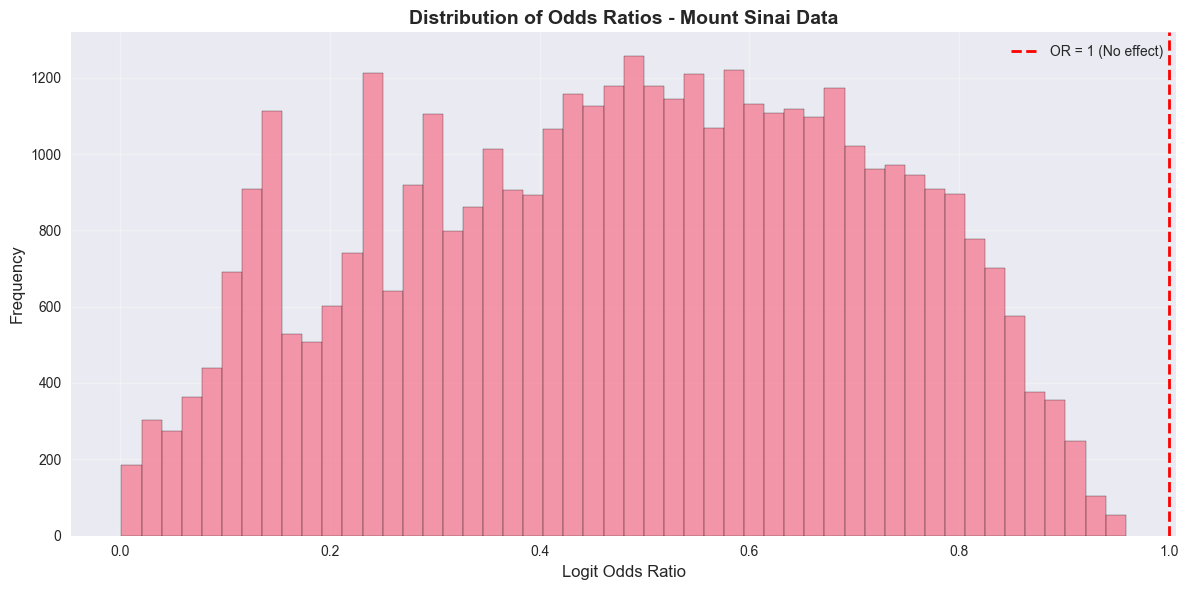

In [14]:
# Distribution of odds ratios (Mount Sinai)
if 'logit_or' in mount_sinai_df.columns:
    plt.figure(figsize=(12, 6))
    plt.hist(mount_sinai_df['logit_or'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(x=1, color='red', linestyle='--', linewidth=2, label='OR = 1 (No effect)')
    plt.xlabel('Logit Odds Ratio', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of Odds Ratios - Mount Sinai Data', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

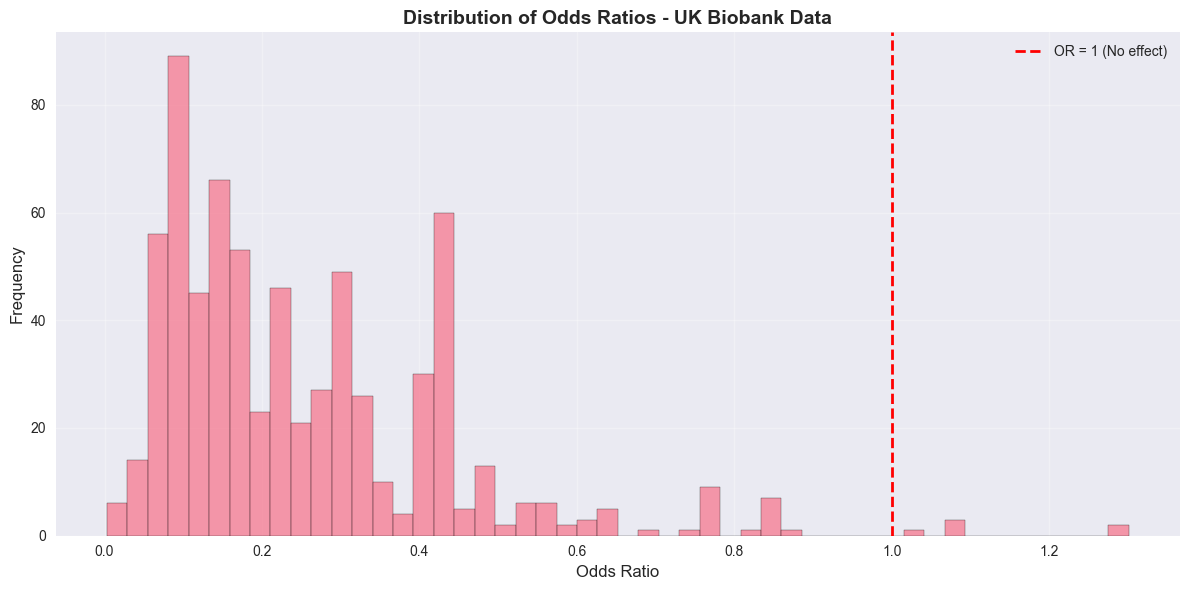

In [15]:
# Distribution of odds ratios (UK Biobank)
if 'odds_ratio' in uk_biobank_df.columns:
    plt.figure(figsize=(12, 6))
    plt.hist(uk_biobank_df['odds_ratio'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(x=1, color='red', linestyle='--', linewidth=2, label='OR = 1 (No effect)')
    plt.xlabel('Odds Ratio', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of Odds Ratios - UK Biobank Data', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()